In [31]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv
/kaggle/input/datasets/ahsanzamanzaman/ahsan-zaman/WA_Fn-UseC_-Telco-Customer-Churn.csv


# Customer Churn Analysis - Week 1 EDA
**Author**: [Ahsan Zaman]
**Date**: [4/3/2026]
**Course**: Introduction to Applied AI
## Project Overview
This notebook performs exploratory data analysis on customer churn data to identify
patterns and inform our predictive modeling approach.
## Table of Contents
1. Dataset Overview
2. Numerical Features Analysis
3. Categorical Features Analysis
4. Feature Correlations
5. Key Insights and Findings


## 1.Load dataset

In [32]:
df = pd.read_csv("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [33]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [34]:
df.shape

(7043, 21)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 2. Visualizing numeric columns

In [36]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

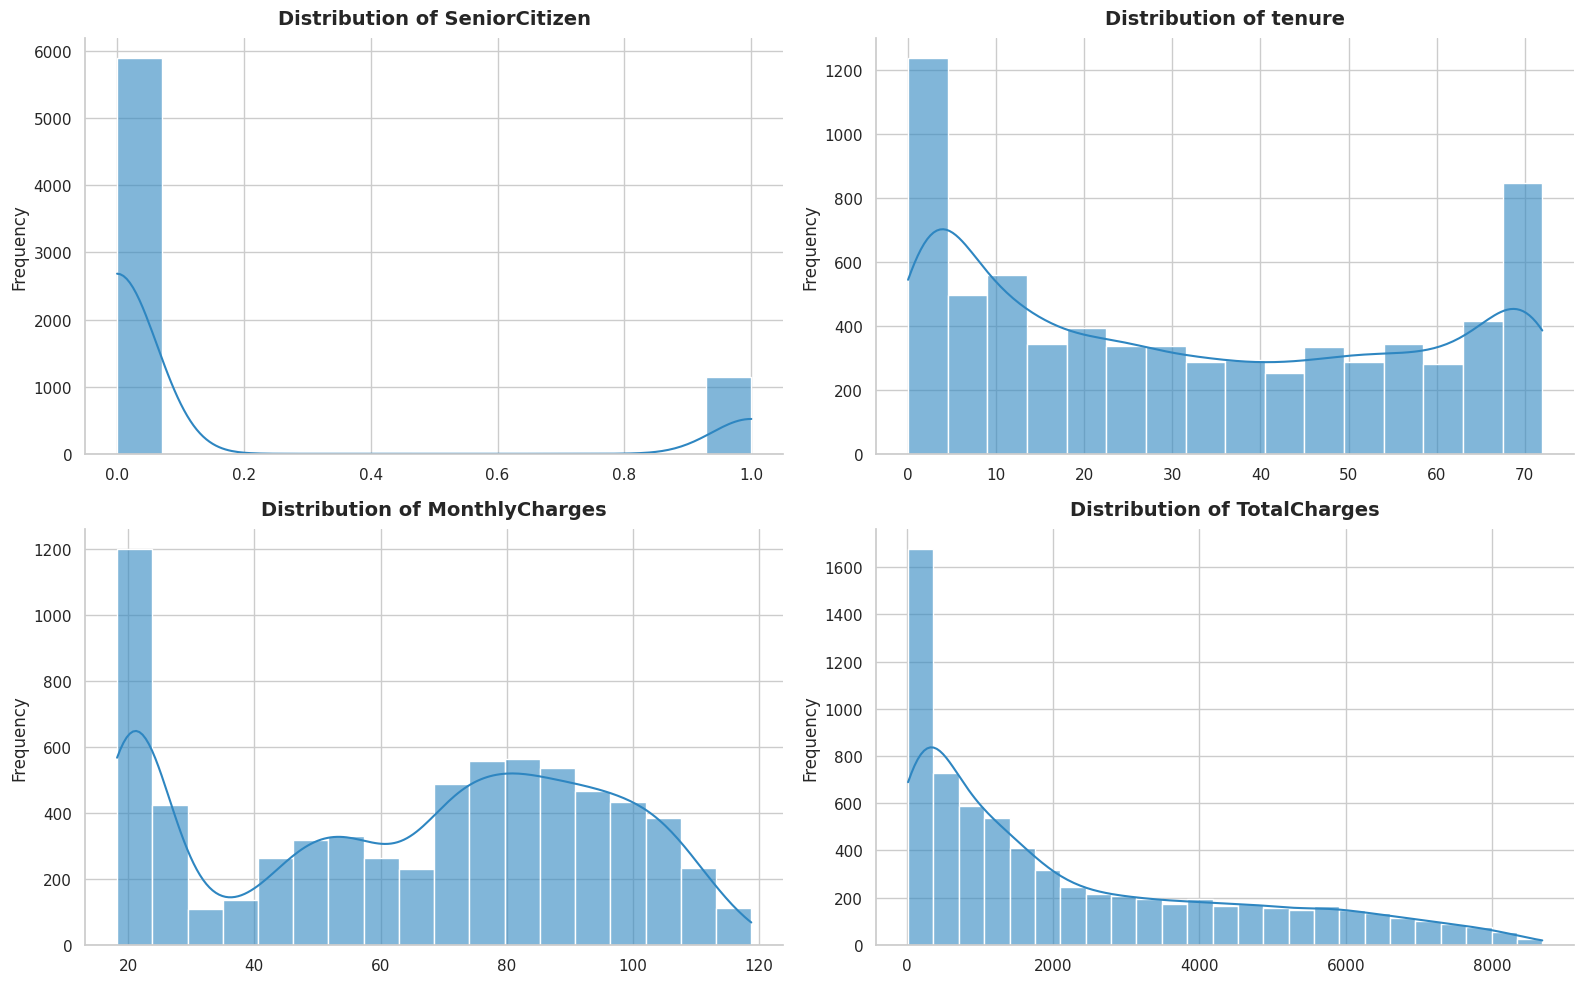

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# 1. Identify all numeric columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
n_cols_count = len(num_cols)

# 2. Calculate grid dimensions (2 columns per row)
n_rows = math.ceil(n_cols_count / 2)

# 3. Setup the figure and axes
fig, axes = plt.subplots(n_rows, 2, figsize=(16, n_rows * 5))
axes = axes.flatten() # Flatten so we can iterate easily

sns.set_theme(style="whitegrid")

# 4. Loop through each numeric column
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#2E86C1", alpha=0.6)
    
    # Professional styling for each subplot
    axes[i].set_title(f'Distribution of {col}', fontsize=14, fontweight='bold', pad=10)
    axes[i].set_xlabel('') # Keep it clean
    axes[i].set_ylabel('Frequency')
    sns.despine(ax=axes[i])

# 5. Remove any empty subplots (if you have an odd number of columns)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 3. Encoding nominal data

In [38]:
df = df.drop('customerID', axis=1)

In [39]:
unique_counts = df.select_dtypes(exclude=['float64', 'int64']).nunique()

print(unique_counts)

gender              2
Partner             2
Dependents          2
PhoneService        2
MultipleLines       3
InternetService     3
OnlineSecurity      3
OnlineBackup        3
DeviceProtection    3
TechSupport         3
StreamingTV         3
StreamingMovies     3
Contract            3
PaperlessBilling    2
PaymentMethod       4
Churn               2
dtype: int64


In [40]:
from sklearn.preprocessing import LabelEncoder

binary_cols = unique_counts[unique_counts == 2].index.tolist()
multi_cols = unique_counts[unique_counts > 2].index.tolist()

# 3. Apply Label Encoding to Binary Columns (0 or 1)
le = LabelEncoder()
for col in binary_cols:
    df[col] = le.fit_transform(df[col])
    print(f"Label Encoded: {col}")

# 4. Apply One-Hot Encoding to Multi-category Columns
# We use drop_first=True to avoid the "Dummy Variable Trap" (Multicollinearity)
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)
print(f"One-Hot Encoded: {multi_cols}")

# Final check
print("\nNew Shape:", df.shape)
df.head()

Label Encoded: gender
Label Encoded: Partner
Label Encoded: Dependents
Label Encoded: PhoneService
Label Encoded: PaperlessBilling
Label Encoded: Churn
One-Hot Encoded: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

New Shape: (7043, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


## 4. Heatmap for correlation checking

We can reduce dimention of features by group high correlation columns

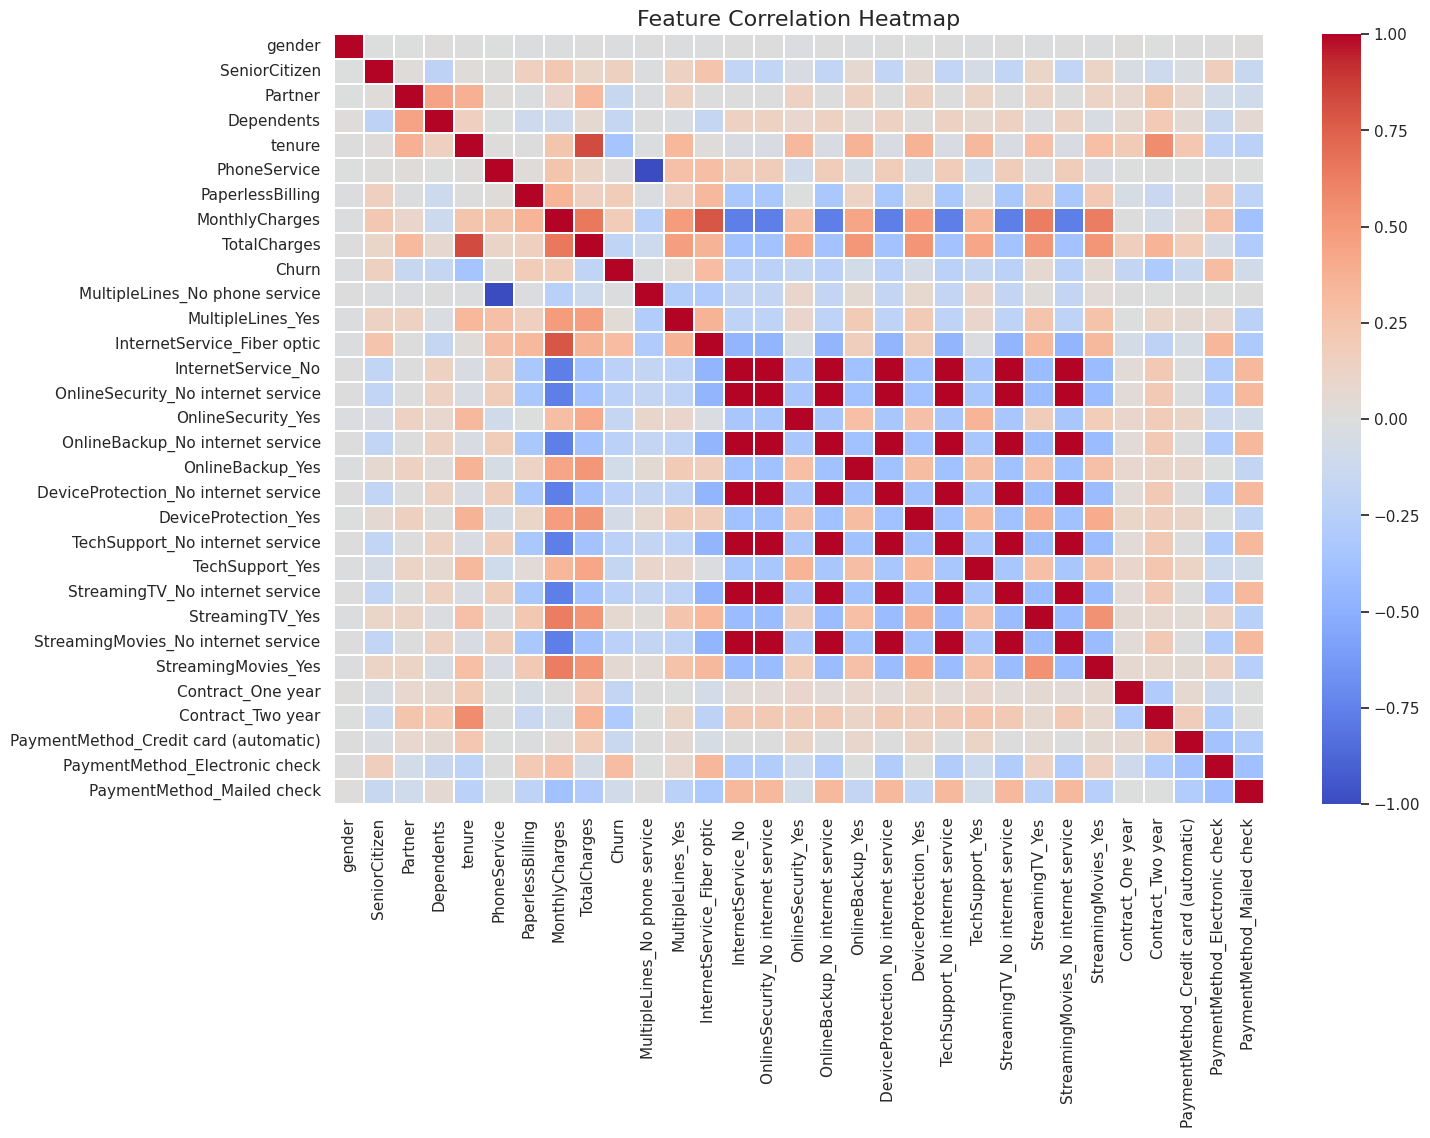

In [41]:
# 1. Calculate the correlation matrix
corr_matrix = df.corr()

# 2. Visualize with a Heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.2)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.savefig('heatmap.png')

## 5. Cleaning data

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7043 non-null   int64  
 1   SeniorCitizen                          7043 non-null   int64  
 2   Partner                                7043 non-null   int64  
 3   Dependents                             7043 non-null   int64  
 4   tenure                                 7043 non-null   int64  
 5   PhoneService                           7043 non-null   int64  
 6   PaperlessBilling                       7043 non-null   int64  
 7   MonthlyCharges                         7043 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7043 non-null   int64  
 10  MultipleLines_No phone service         7043 non-null   bool   
 11  Mult

In [43]:
print(df.isnull().sum())

gender                                    0
SeniorCitizen                             0
Partner                                   0
Dependents                                0
tenure                                    0
PhoneService                              0
PaperlessBilling                          0
MonthlyCharges                            0
TotalCharges                             11
Churn                                     0
MultipleLines_No phone service            0
MultipleLines_Yes                         0
InternetService_Fiber optic               0
InternetService_No                        0
OnlineSecurity_No internet service        0
OnlineSecurity_Yes                        0
OnlineBackup_No internet service          0
OnlineBackup_Yes                          0
DeviceProtection_No internet service      0
DeviceProtection_Yes                      0
TechSupport_No internet service           0
TechSupport_Yes                           0
StreamingTV_No internet service 

In [44]:
# 1. Drop rows where TotalCharges is NaN
df.dropna(subset=['TotalCharges'], inplace=True)

# 2. Verify that there are zero missing values left
print(f"Missing values in TotalCharges: {df['TotalCharges'].isnull().sum()}")
print(f"New DataFrame shape: {df.shape}")

Missing values in TotalCharges: 0
New DataFrame shape: (7032, 31)


In [45]:
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)


In [46]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,0,0,0,1,0


## 6. Scaling numeric columns

In [47]:
from sklearn.preprocessing import MinMaxScaler

# 1. Apply Log Transformation to TotalCharges
# np.log1p handles 0 values by calculating log(1+x)
df['TotalCharges'] = np.log1p(df['TotalCharges'])

# 2. Apply Min-Max Scaling to tenure and MonthlyCharges
# This squashes values into a range between 0 and 1
scaler = MinMaxScaler()
cols_to_scale = ['tenure', 'MonthlyCharges']

df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

# 3. Final verification
print(df[['TotalCharges', 'tenure', 'MonthlyCharges']].head())

   TotalCharges    tenure  MonthlyCharges
0      3.429137  0.000000        0.115423
1      7.544597  0.464789        0.385075
2      4.692723  0.014085        0.354229
3      7.518471  0.619718        0.239303
4      5.028148  0.014085        0.521891


In [48]:
df['TotalCharges'] = scaler.fit_transform(df[['TotalCharges']])

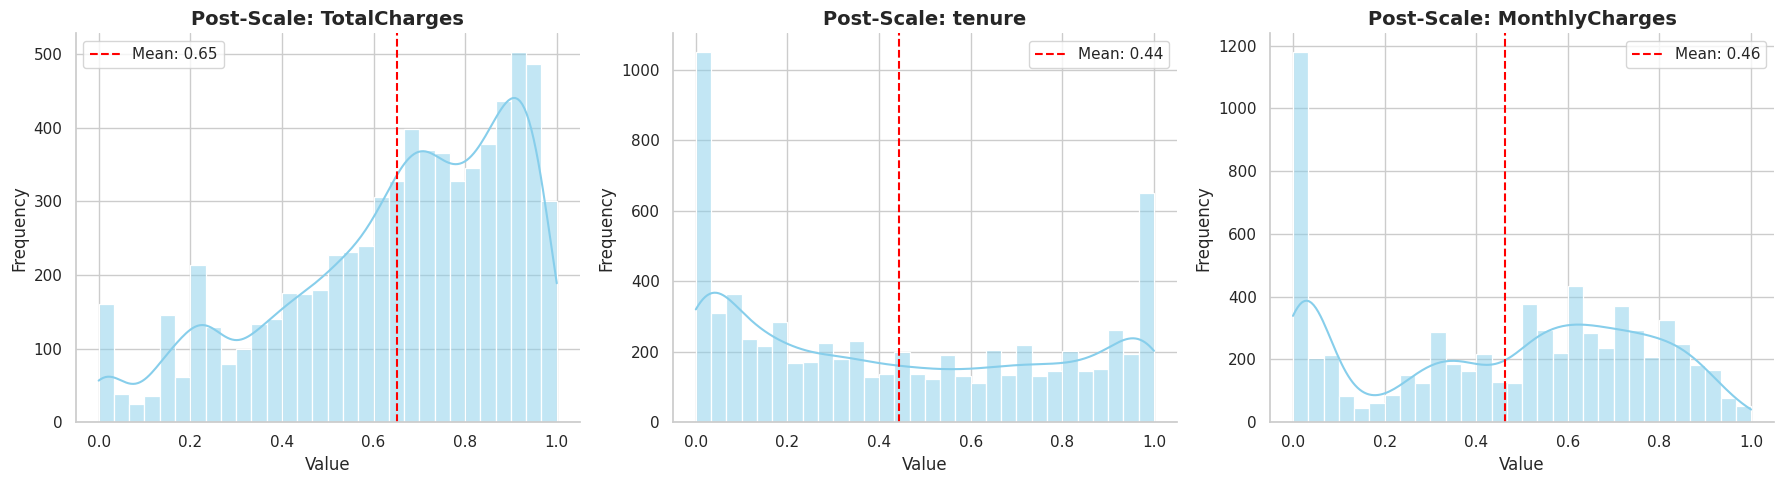

In [49]:
# Define the features we just transformed
features = ['TotalCharges', 'tenure', 'MonthlyCharges']

# Create a 1x3 grid for side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(features):
    # Plot histogram with Kernel Density Estimate
    sns.histplot(df[col], kde=True, ax=axes[i], color="skyblue", bins=30)
    
    # Add titles and clean labels
    axes[i].set_title(f'Post-Scale: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    
    # Add a vertical line at the mean for reference
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
    axes[i].legend()

sns.despine()
plt.tight_layout()
plt.show()

## 7. Checking class imbalance

In [50]:
churn_number = df[df['Churn']==1]['Churn'].count()
churn_ratio = churn_number/df.shape[0]
print(f"Percentage of churn customer: {churn_ratio}")

Percentage of churn customer: 0.26578498293515357


## 8. Spliting data

In [51]:
from sklearn.model_selection import train_test_split

# Define Target and Features
X = df.drop(columns=['Churn'], errors='ignore')
y = df['Churn']

In [52]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.3, random_state=42, stratify=y_train_val
)

In [53]:
# 60% Train, 20% Val, 20% Test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

## 9. Training with Logistic Regression and Evaluate

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Initialize Logistic Regression
# 'balanced' handles the 26% churn imbalance automatically
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

# Train
lr_model.fit(X_train, y_train)

# Get probabilities for evaluation
lr_probs = lr_model.predict_proba(X_val)[:, 1]

In [55]:
from sklearn.metrics import recall_score, precision_score
y_pred_hard = (lr_probs >= 0.5).astype(int)
# 2. Calculate metrics
recall = recall_score(y_val, y_pred_hard)
precision = precision_score(y_val, y_pred_hard)

print(f"At 0.5 threshold -> Recall: {recall:.2f}, Precision: {precision:.2f}")

At 0.5 threshold -> Recall: 0.77, Precision: 0.53


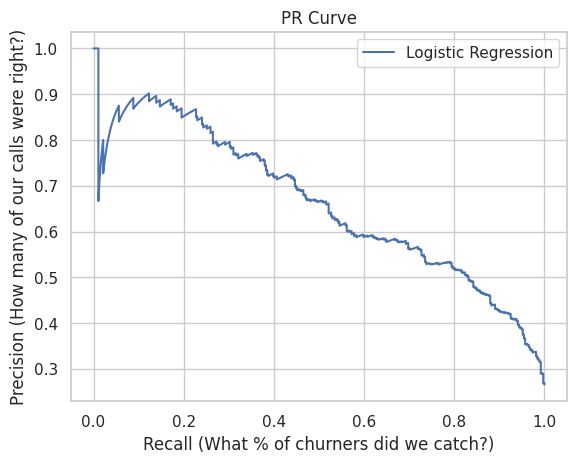

In [56]:
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_val, lr_probs)
plt.plot(recalls, precisions, label='Logistic Regression')
plt.xlabel('Recall (What % of churners did we catch?)')
plt.ylabel('Precision (How many of our calls were right?)')
plt.title('PR Curve')
plt.legend()
plt.grid(True)
plt.show()

## 10. Traing with XGB and RF with Hyperparameter Tuning

### 10.a Training

In [57]:
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 1. XGBoost Hyperparameter Search
xgb_params = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'scale_pos_weight': [3] # Balance for Churn
}
xgb_grid = GridSearchCV(XGBClassifier(random_state=42), xgb_params, scoring='average_precision', cv=3)
xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_

# 2. Random Forest Hyperparameter Search
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'class_weight': ['balanced']
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, scoring='average_precision', cv=3)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

### 10.b Compare 3 models

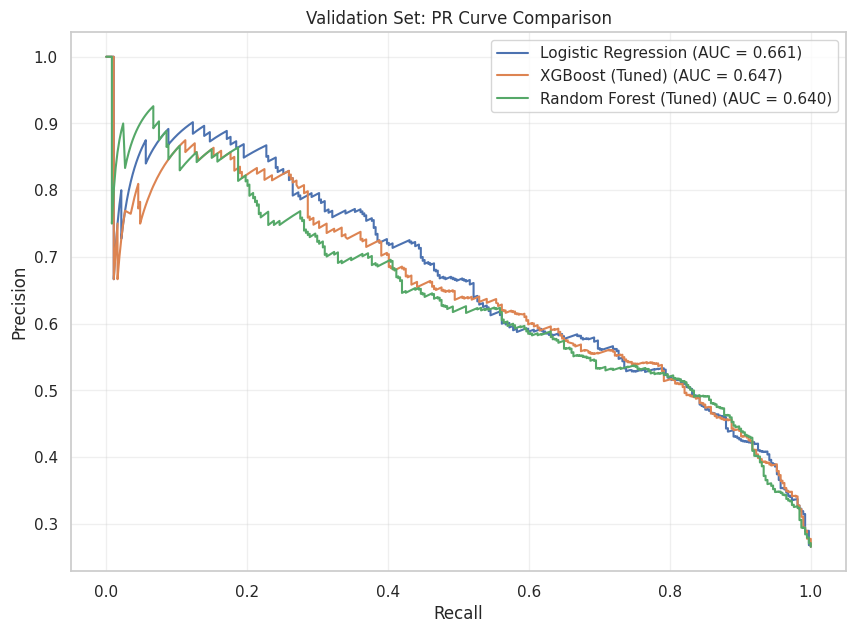

In [58]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# Get probabilities from Validation Set
models = {
    "Logistic Regression": lr_model.predict_proba(X_val)[:, 1],
    "XGBoost (Tuned)": best_xgb.predict_proba(X_val)[:, 1],
    "Random Forest (Tuned)": best_rf.predict_proba(X_val)[:, 1]
}

plt.figure(figsize=(10, 7))

for name, probs in models.items():
    precision, recall, _ = precision_recall_curve(y_val, probs)
    pr_auc = auc(recall, precision)
    plt.plot(recall, precision, label=f'{name} (AUC = {pr_auc:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Validation Set: PR Curve Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Overall, LR have the highest AUC so it would be the best for now.

## 11. Feature importance 

In [59]:
# 1. Get feature names and coefficients
# Note: X_train must be a DataFrame or you must have the column list saved
feature_names = X.columns 
coefficients = lr_model.coef_[0]

# 2. Create a DataFrame for easy sorting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Weight': coefficients,
    'Abs_Weight': np.abs(coefficients) # For ranking total impact
})

# 3. Sort by absolute impact
importance_df = importance_df.sort_values(by='Abs_Weight', ascending=False)

print(importance_df[['Feature', 'Weight']].head(10))

                        Feature    Weight
8                  TotalCharges -3.330137
26            Contract_Two year -1.666108
11  InternetService_Fiber optic  1.173050
25            Contract_One year -0.907760
10            MultipleLines_Yes  0.457888
24          StreamingMovies_Yes  0.437427
22              StreamingTV_Yes  0.366254
14           OnlineSecurity_Yes -0.323488
3                    Dependents -0.273851
20              TechSupport_Yes -0.272737


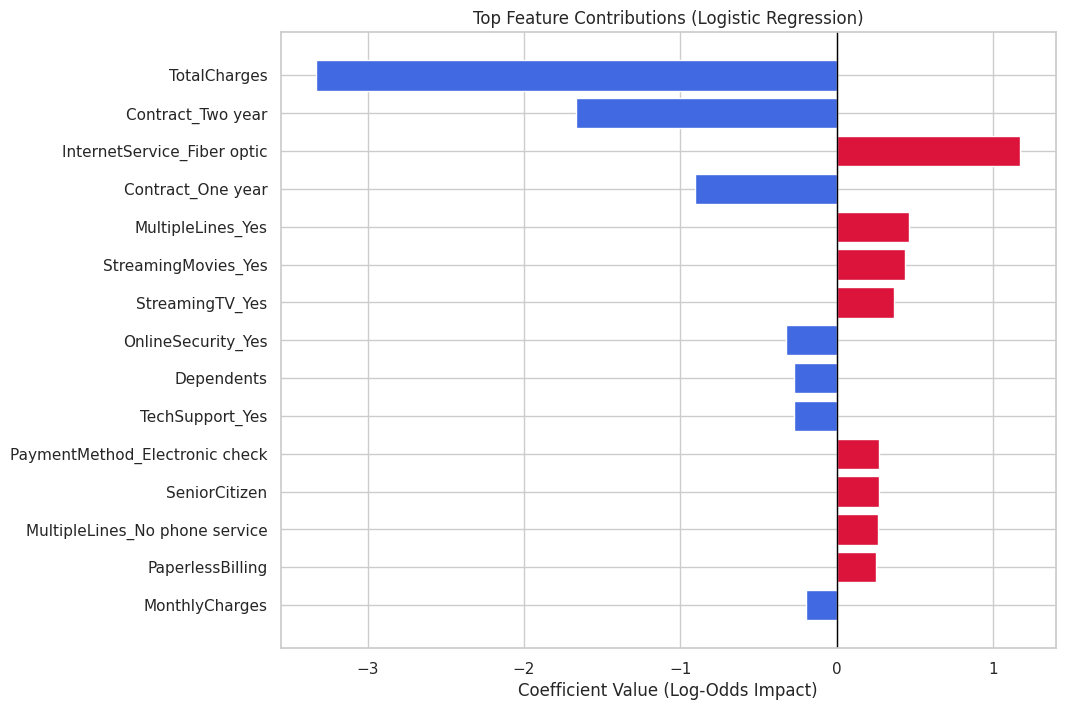

In [60]:
plt.figure(figsize=(10, 8))
# Plotting top 15 features
top_n = 15
colors = ['crimson' if x > 0 else 'royalblue' for x in importance_df['Weight'][:top_n]]

plt.barh(importance_df['Feature'][:top_n], importance_df['Weight'][:top_n], color=colors)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.title('Top Feature Contributions (Logistic Regression)')
plt.xlabel('Coefficient Value (Log-Odds Impact)')
plt.gca().invert_yaxis() # Highest impact at the top
plt.show()

# Telco Customer Churn – What I Understood

## Introduction
In this notebook, I learned how to analyze a **Telco Customer Churn dataset** and apply machine learning models to predict whether a customer will leave the company. The main goal is to understand customer behavior and build models that can accurately predict churn.

Customer churn prediction is important because it helps companies identify customers who may leave and take actions to retain them.

---

## Dataset Overview
The dataset contains information about telecom customers. It includes details about:

- Customer demographics
- Services subscribed by customers
- Account information
- Payment methods
- Monthly and total charges
- Whether the customer churned or not

The **target variable** in this dataset is **Churn**, which indicates if the customer left the service.

---

## Data Exploration
At the beginning of the notebook, the dataset is explored to understand its structure.

This includes:
- Checking the number of rows and columns
- Viewing the first few records
- Understanding column names
- Identifying data types

This step helps in getting a basic understanding of the dataset.

---

## Data Cleaning
Before applying machine learning models, the data must be cleaned.

The notebook performs several preprocessing steps such as:

- Handling missing values
- Converting data types
- Removing unnecessary columns if needed

Clean data improves the quality and accuracy of machine learning models.

---

## Feature Analysis
The notebook analyzes different features to understand how they relate to churn.

### Numerical Features
These include values such as:

- Tenure
- MonthlyCharges
- TotalCharges

Statistical analysis and visualizations are used to understand their distribution.

### Categorical Features
These include variables such as:

- Gender
- Internet service
- Contract type
- Payment method

These features help identify patterns in customer behavior.

---

## Data Visualization
Visualization is used to better understand patterns in the dataset.

Different plots are used to observe:

- Distribution of numerical variables
- Frequency of categorical variables
- Relationship between features and churn

Visualization helps reveal trends that may not be obvious from raw data.

---

## Data Preprocessing for Machine Learning
Before training models, the data must be converted into a suitable format.

Steps include:

- Encoding categorical variables
- Splitting the dataset into training and testing sets
- Scaling numerical features if necessary

These steps prepare the dataset for machine learning algorithms.

---

## Machine Learning Models
Several machine learning models are used to predict customer churn. These models are trained on the dataset and their performance is evaluated.

Examples of models that may be used include:

- Logistic Regression
- Decision Tree
- Random Forest
- Support Vector Machine
- K-Nearest Neighbors

Each model learns patterns in the data and predicts whether a customer will churn.

---

## Model Evaluation
After training the models, their performance is compared using evaluation metrics such as:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix

These metrics help determine which model performs best for churn prediction.

---

## Choosing the Best Model
After evaluating all models, the notebook selects the model with the best performance. The best model is the one that predicts churn most accurately while minimizing errors.

Selecting the best model is important for making reliable predictions in real-world scenarios.

---

## Conclusion
From this notebook, I learned how to perform a complete machine learning workflow for customer churn prediction. The process includes:

1. Understanding the dataset  
2. Cleaning and preprocessing the data  
3. Exploring features using visualization  
4. Training multiple machine learning models  
5. Evaluating and selecting the best model  

This project demonstrates how machine learning can be used to help businesses predict customer churn and improve customer retention.

---

## Key Takeaways
- Data exploration is essential before building models.
- Proper preprocessing improves model performance.
- Different machine learning models should be tested and compared.
- Evaluation metrics help determine the best model.

Predicting customer churn can help companies take preventive actions and improve customer satisfaction.
